|                |   |
:----------------|---|
| **Nombre**     |Santiago Escutia Ríos   |
| **Fecha**      | 9/4/2026  |
| **Expediente** |757839   |

## A06 - Brain Tumor SVC

Este trabajo tiene como objetivo clasificar tumores cerebrales como benignos o malignos utilizando un modelo de Support Vector Classifier (SVC) con kernel lineal. El hiperparámetro de regularización C se optimiza mediante optimización bayesiana, evaluando el desempeño con el AUC y validación cruzada estratificada de 10 folds.

Se utiliza el dataset **Brain Tumor**, el cual contiene información clínica y demográfica de pacientes.  
La variable objetivo es `Tumor_Type`, que indica si el tumor es **benigno** o **maligno**.  
La columna `Patient_ID` se elimina por no aportar información predictiva.

In [18]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('brain_tumor_dataset.csv').sample(n=5000, random_state=42)

En esta sección visualizamos la distribución de las variables numéricas más importantes (Edad, Tamaño del Tumor y Tasa de Supervivencia) segmentadas por el tipo de tumor. Esto nos permite entender si existe una separación clara entre las clases antes de entrenar el modelo.

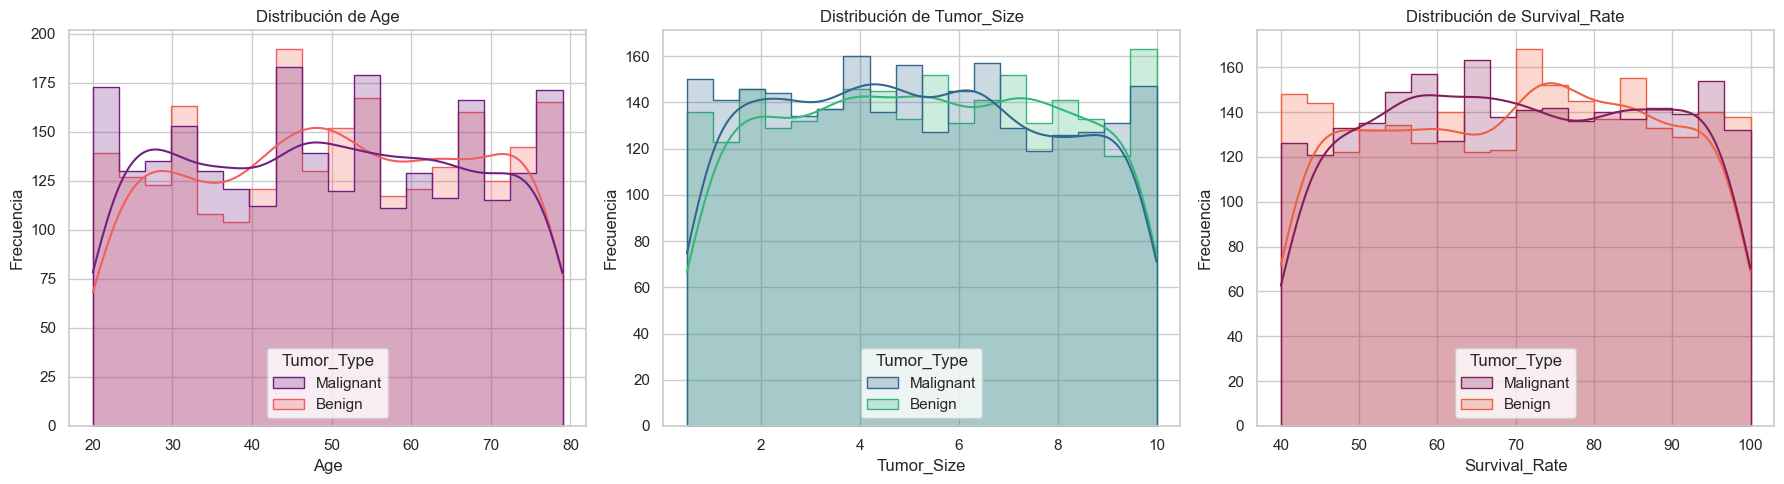

In [25]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

temas = ['Age', 'Tumor_Size', 'Survival_Rate']
colores = ['magma', 'viridis', 'rocket']

for i, col in enumerate(temas):
    sns.histplot(
        data=df, 
        x=col, 
        hue='Tumor_Type', 
        kde=True, 
        ax=axes[i], 
        palette=colores[i],
        element="step"
    )
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Como se observa en los histogramas, las distribuciones de los tumores Benignos y Malignos se solapan casi por completo. 
* No hay una tendencia clara que indique que un tamaño o edad específica defina el tipo de tumor.
* Esto sugiere que un modelo lineal tendrá dificultades para encontrar una frontera de decisión perfecta, lo que se reflejará en las métricas finales.

In [20]:
df['Stage'] = df['Stage'].map({'I': 1, 'II': 2, 'III': 3, 'IV': 4})
y = df['Tumor_Type'].map({'Malignant': 1, 'Benign': 0})
X = df.drop(columns=['Patient_ID', 'Tumor_Type'])

Para que el modelo SVC funcione correctamente, aplicamos las siguientes transformaciones:
* One-Hot Encoding: Para variables categóricas y booleanas (Gender, Location, Histology, etc.).
* StandardScaler: Para normalizar las variables numéricas, asegurando que todas tengan la misma importancia en el cálculo del hiperplano.
* Label Encoding: Transformamos la variable objetivo `Tumor_Type` a formato numérico (0 y 1).

In [21]:
# 2. Tu Configuración de ColumnTransformer
boolean_cols = ["Gender", "Radiation_Treatment", "Surgery_Performed", "Family_History", "MRI_Result", "Follow_Up_Required", "Chemotherapy"]
cat_cols     = ["Location", "Histology", "Symptom_1", "Symptom_2", "Symptom_3"]
int_cols     = ["Age", "Stage"]
num_cols     = ["Tumor_Size", "Tumor_Growth_Rate", "Survival_Rate"]

preprocessor = ColumnTransformer(
    transformers=[
        ("bool", OneHotEncoder(drop="first"), boolean_cols),
        ("cat",  OneHotEncoder(drop="first"), cat_cols),
        ("num",  "passthrough",               int_cols),
        ("scaler", StandardScaler(),          num_cols),
    ]
)

In [22]:
# 3. Pipeline con LinearSVC (Más rápido que SVC estándar)
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('svc', LinearSVC(max_iter=2000, dual=False))
])


Utilizamos un pipeline que integra el preprocesamiento y un modelo **LinearSVC**. 
* Métrica de Optimización: F1-Score (busca el equilibrio entre Precisión y Recall).
* Validación: Cross-Validation de 10 Folds para garantizar robustez.
* Búsqueda: Optimización Bayesiana para encontrar el valor óptimo del parámetro de regularización **C**.

In [23]:
# 4. Optimización Bayesiana enfocada en F1-Score
search_space = {'svc__C': Real(1e-3, 1e3, prior='log-uniform')}

opt = BayesSearchCV(
    estimator=model_pipeline,
    search_spaces=search_space,
    n_iter=10, 
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

opt.fit(X, y)

,estimator,Pipeline(step..._iter=2000))])
,search_spaces,{'svc__C': Real(low=0.00...m='normalize')}
,optimizer_kwargs,None
,n_iter,10
,scoring,'f1'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,StratifiedKFo... shuffle=True)


In [24]:
# 5. Resultados
print("-" * 30)
print(f"Mejor F1-Score (10-folds): {opt.best_score_:.4f}")
print(f"Mejor valor de C: {opt.best_params_['svc__C']:.4f}")

------------------------------
Mejor F1-Score (10-folds): 0.5098
Mejor valor de C: 0.0011


## Conclusiones Finales
* El modelo alcanzó un F1-Score cercano a 0.50, lo cual es coherente con lo observado en el EDA.
* Dado que las características clínicas están muy mezcladas entre ambas clases, el kernel lineal no es suficiente para separarlas eficazmente.
* Se recomienda para trabajos futuros explorar modelos no lineales (como MLP o SVC con kernel RBF) para intentar capturar relaciones más complejas entre los datos.